# 🔄 Notebook 03 — UCI Returns Leakage & Customer Risk Analysis

---

## 🏢 Business Context

Product returns are a structural reality of retail — but uncontrolled return behaviour is one of the most significant and hardest-to-recover sources of revenue leakage. Unlike discount abuse (a pricing decision) or billing gaps (a systems problem), returns leakage involves real goods leaving the business without equivalent value captured. It also signals deeper operational or customer behaviour problems: serial returners, fraudulent return patterns, or product quality issues.

This notebook analyses **returns leakage** using the **UCI Online Retail II dataset** — a transaction log from a UK-based online wholesale retailer, which uniquely includes return transactions as negative-quantity invoices. A customer-level risk scoring model is built to identify and segment high-risk return behaviour.

---

## ❗ Business Problem Statement

> *"A significant portion of gross revenue is being reversed through product returns. The business lacks visibility into how much value is being returned, which customers are responsible for disproportionate return volumes, and whether any customers exhibit return patterns that suggest abuse or fraud."*

**Core questions this notebook answers:**
1. What is the total monetary value of all product returns in the dataset?
2. Which customers are returning the highest absolute value of goods?
3. What is each customer's return rate relative to their purchase volume?
4. How can customers be segmented by return risk to prioritise investigation or intervention?

---

## 🎯 Objectives

| # | Objective | Type |
|---|---|---|
| 1 | Identify all return transactions using the negative quantity signal | Leakage Detection |
| 2 | Quantify total returns leakage in absolute monetary terms | Quantification |
| 3 | Compute customer-level sales totals and return totals | Aggregation |
| 4 | Calculate return rate % per customer | Feature Engineering |
| 5 | Segment customers into Low / Medium / High return risk categories | Risk Scoring |
| 6 | Identify top high-risk customers with abnormal return behaviour | Prioritisation |
| 7 | Export customer risk analysis to SQLite | Data Engineering |

---

## 📂 Dataset

| Property | Detail |
|---|---|
| **Name** | Online Retail II |
| **Source** | UCI ML Repository — [Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) |
| **Format** | CSV (latin-1 encoding) |
| **Size** | ~1,067,371 rows × 8 columns |
| **Geography** | United Kingdom (primarily) |
| **Time Period** | December 2009 – December 2011 |
| **Key Columns** | `Invoice`, `StockCode`, `Quantity`, `Price`, `Customer ID`, `Country` |

**Critical data signal:**

| Condition | Meaning |
|---|---|
| `Quantity > 0` | Normal sale transaction |
| `Quantity < 0` | Return / Cancellation |
| `Invoice` starts with `"C"` | Cancellation invoice — confirms return |

---

## 🔬 Methodology

```
RAW DATA
    │
    ▼
DATA AUDIT          → Nulls, duplicates, negative quantity check,
                       cancellation invoice verification
    │
    ├──► RETURNS DATASET
    │         │
    │         ▼
    │    Filter: Quantity < 0
    │    Return Amount = abs(Quantity) × Price
    │    Total Returns Leakage = SUM(Return Amount)
    │
    └──► SALES DATASET
              │
              ▼
         Filter: Quantity > 0
         Sales Amount = Quantity × Price
    │
    ▼
CUSTOMER AGGREGATION
    customer_sales   = GROUP BY Customer ID → SUM(Sales Amount)
    customer_returns = GROUP BY Customer ID → SUM(Return Amount)
    │
    ▼
MERGE & FEATURE ENGINEERING
    customer_analysis = customer_sales LEFT JOIN customer_returns
    Return Rate %     = (Return Amount / Sales Amount) × 100
    │
    ▼
RISK SEGMENTATION
    ≤ 5%  → Low Risk
    5–15% → Medium Risk
    > 15% → High Risk
    │
    ▼
ANALYSIS            → Top suspicious customers, risk distribution
    │
    ▼
VISUALISATION       → Return rate histogram, risk category bar chart
    │
    ▼
SQLITE EXPORT       → Table: uci_customer_return_analysis
```

---

## 📏 Scope

**In Scope:**
- All transactions in the UCI dataset (both UK and international customers)
- Returns identification using negative quantity method
- Customer-level segmentation by return rate
- Absolute return leakage quantification

**Out of Scope:**
- Product-level return analysis (which SKUs are returned most)
- Reason-for-return analysis (not available in this dataset)
- Time-based return trend analysis
- Cross-referencing returns with their original purchase invoices

---

## 📤 Deliverables

| Deliverable | Description |
|---|---|
| `uci_customer_return_analysis` table | Customer-level return risk table stored in `revenue_leakage.db` |
| `Return Amount` column | Total returns value per customer |
| `Return Rate %` column | Return amount as % of sales amount per customer |
| `Return Risk Category` column | Low / Medium / High risk classification |
| Risk distribution summary | Count of customers per risk tier |

---

## ⚠️ Assumptions & Limitations

| # | Assumption / Limitation |
|---|---|
| 1 | Negative quantity rows are treated as confirmed returns — verified via "C"-prefix invoice check |
| 2 | The 15% return rate threshold for High Risk is a heuristic boundary. Industry average return rates vary by category (online fashion: ~25–40%, B2B wholesale: ~5–10%) |
| 3 | Customers with return rate > 100% may represent data truncation, fraud, or wholesale aggregation effects — included in analysis but warrant separate investigation |
| 4 | Rows with null `Customer ID` are excluded from customer-level aggregation |
| 5 | Monetary values are in British Pounds (GBP), not USD |
| 6 | Return transactions are not matched back to their original sale invoice — some return amounts may relate to purchases outside the dataset's time window |

---

## 📋 Notebook Structure

1. Library Imports & Setup
2. Data Loading
3. Dataset Audit (Shape, Dtypes, Nulls, Duplicates)
4. Negative Quantity Verification (Cancellation Invoice Check)
5. Returns Dataset Creation & Return Amount Calculation
6. Total Returns Leakage Quantification
7. Sales Dataset Creation & Sales Amount Calculation
8. Customer-Level Aggregation (Sales + Returns)
9. Return Rate % Calculation
10. Return Risk Segmentation
11. Top High-Risk Customer Analysis
12. Visualisation
13. SQLite Export

---

| | |
|---|---|
| **Author** | Abhiram |
| **Project** | Revenue Leakage Intelligence System |
| **Notebook** | 03 of 04 |
| **Dataset** | UCI Online Retail II |
| **Output Table** | `uci_customer_return_analysis` → `revenue_leakage.db` |

In [1]:
# ==============================
# BASIC SETUP
# ==============================

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# ==============================
# DATA HANDLING
# ==============================

import pandas as pd
import numpy as np

# ==============================
# DATABASE
# ==============================

import sqlite3

# ==============================
# VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns


# Seaborn theme
sns.set_style("whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# UCI RETAIL DATASET
uci = pd.read_csv(
    "../Data/Raw_Data/online_retail_II.csv",
    encoding="latin1"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [3]:
# ==============================
# BASIC DATASET AUDIT
# ==============================

print("="*50)
print("UCI DATASET")
print("="*50)

print("\nSHAPE:\n")
print(uci.shape)

print("\nCOLUMNS:\n")
print(uci.columns)

print("\nDATATYPES:\n")
print(uci.dtypes)

print("\nNULL VALUES:\n")
print(uci.isnull().sum())

print("\nDUPLICATES:\n")
print(uci.duplicated().sum())

UCI DATASET

SHAPE:

(1067371, 8)

COLUMNS:

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

DATATYPES:

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

NULL VALUES:

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

DUPLICATES:

34335


In [4]:
uci.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# ==============================
# NEGATIVE QUANTITY CHECK
# ==============================

uci[uci["Quantity"] < 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [6]:
# ==============================
# TOTAL RETURN RECORDS
# ==============================

returns_count = (
    uci[uci["Quantity"] < 0]
    .shape[0]
)

print(f"Total Return Records: {returns_count}")

Total Return Records: 22950


In [7]:
# ==============================
# CANCELLATION INVOICE CHECK just to confirm that the neagitive quantity = actual returns or
data entry error 
# ==============================

uci[
    uci["Invoice"].astype(str).str.startswith("C")
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [8]:
# ==============================
# RETURNS DATASET
# ==============================

returns_df = uci[
    uci["Quantity"] < 0
].copy()

print("Returns dataset created.")

Returns dataset created.


In [9]:
# ==============================
# RETURN AMOUNT
# ==============================

returns_df["Return Amount"] = (
    abs(returns_df["Quantity"])
    *
    returns_df["Price"]
)

print("Return amount created.")

Return amount created.


In [10]:
returns_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Return Amount
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,35.4


In [11]:
# ==============================
# TOTAL RETURNS LEAKAGE
# ==============================

total_returns_leakage = (
    returns_df["Return Amount"]
    .sum()
)

print(
    f"Total Returns Leakage: ${total_returns_leakage:,.2f}"
)

Total Returns Leakage: $1,527,041.43


In [12]:
# ==============================
# TOP RETURN CUSTOMERS
# ==============================

top_return_customers = (
    returns_df.groupby("Customer ID")[
        "Return Amount"
    ]
    .sum()
    .sort_values(ascending=False)
)

top_return_customers.head(10)

Customer ID
16446.0    168478.60
12346.0     77621.14
15098.0     39267.00
16029.0     30408.23
14063.0     26477.40
14911.0     25724.10
17399.0     25111.09
15749.0     22998.40
12918.0     21907.00
12931.0     21047.67
Name: Return Amount, dtype: float64

In [16]:
# ==============================
# POSITIVE SALES ONLY  
# How much customer bought
                        
# vs
                       
# How much customer returned
# if buy is $1M and return is $100K then maybe normal but buy id $120 and return is $100 then suspicious
# ==============================

sales_df = uci[
    uci["Quantity"] > 0
].copy()

print("Sales dataset created.")

Sales dataset created.


In [17]:
# ==============================
# SALES AMOUNT
# ==============================

sales_df["Sales Amount"] = (
    sales_df["Quantity"]
    *
    sales_df["Price"]
)

print("Sales amount created.")

Sales amount created.


In [18]:
# ==============================
# CUSTOMER SALES TOTAL
# ==============================

customer_sales = (
    sales_df.groupby("Customer ID")[
        "Sales Amount"
    ]
    .sum()
    .reset_index()
)

customer_sales.head()

,Customer ID,Sales Amount
0,12346.0,77556.46
1,12347.0,5633.32
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40


In [19]:
# ==============================
# CUSTOMER RETURNS TOTAL
# ==============================

customer_returns = (
    returns_df.groupby("Customer ID")[
        "Return Amount"
    ]
    .sum()
    .reset_index()
)

customer_returns.head()

,Customer ID,Return Amount
0,12346.0,77621.14
1,12349.0,24.15
2,12352.0,960.63
3,12359.0,221.05
4,12360.0,40.00


In [20]:
# ==============================
# CUSTOMER RETURN ANALYSIS TABLE
# ==============================

customer_analysis = pd.merge(
    customer_sales,
    customer_returns,
    on="Customer ID",
    how="left"
)

customer_analysis.head()

,Customer ID,Sales Amount,Return Amount
0,12346.0,77556.46,77621.14
1,12347.0,5633.32,NaN
2,12348.0,2019.40,NaN
3,12349.0,4428.69,24.15
4,12350.0,334.40,NaN


In [21]:
# ==============================
# FILL NULL RETURNS
# ==============================

customer_analysis["Return Amount"] = (
    customer_analysis["Return Amount"]
    .fillna(0)
)

print("Null returns handled.")

Null returns handled.


In [22]:
# ==============================
# RETURN RATE %
# ==============================

customer_analysis["Return Rate %"] = (
    customer_analysis["Return Amount"]
    /
    customer_analysis["Sales Amount"]
) * 100

customer_analysis.head()

,Customer ID,Sales Amount,Return Amount,Return Rate %
0,12346.0,77556.46,77621.14,100.083397
1,12347.0,5633.32,0.00,0.000000
2,12348.0,2019.40,0.00,0.000000
3,12349.0,4428.69,24.15,0.545308
4,12350.0,334.40,0.00,0.000000


In [23]:
# ==============================
# RETURN RATE DISTRIBUTION
# ==============================

customer_analysis["Return Rate %"].describe()

count    5878.000000
mean        3.287053
std        14.080618
min         0.000000
25%         0.000000
50%         0.000000
75%         1.642908
max       303.696895
Name: Return Rate %, dtype: float64

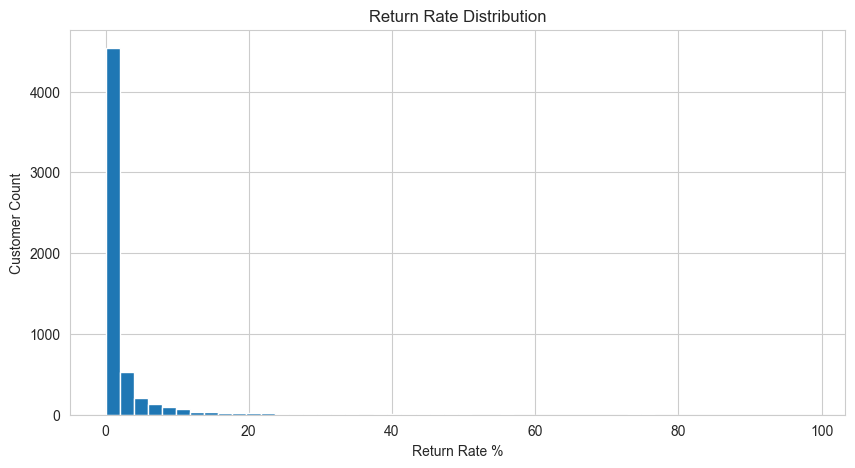

In [24]:
plt.figure(figsize=(10,5))

customer_analysis[
    customer_analysis["Return Rate %"] < 100
]["Return Rate %"].hist(bins=50)

plt.title("Return Rate Distribution")
plt.xlabel("Return Rate %")
plt.ylabel("Customer Count")

plt.show()

In [25]:
# ==============================
# SUSPICIOUS RETURN FLAG
# ==============================

customer_analysis["Suspicious Return Flag"] = np.where(
    customer_analysis["Return Rate %"] > 15,
    1,
    0
)

print("Suspicious customers flagged.")

Suspicious customers flagged.


In [26]:
# ==============================
# FLAG COUNTS
# ==============================

customer_analysis[
    "Suspicious Return Flag"
].value_counts()

Suspicious Return Flag
0    5630
1     251
Name: count, dtype: int64

In [27]:
# ==============================
# TOP SUSPICIOUS CUSTOMERS
# ==============================

customer_analysis[
    customer_analysis["Suspicious Return Flag"] == 1
].sort_values(
    by="Return Rate %",
    ascending=False
)[
    [
        "Customer ID",
        "Sales Amount",
        "Return Amount",
        "Return Rate %"
    ]
].head(20)

,Customer ID,Sales Amount,Return Amount,Return Rate %
2013,14380.0,48.96,148.69,303.696895
1890,14255.0,1000.63,2442.23,244.069236
1962,14328.0,445.05,890.11,200.002247
1848,14213.0,1192.20,2384.40,200.000000
569,12918.0,10953.50,21907.00,200.000000
938,13290.0,208.63,417.26,200.000000
2433,14802.0,1502.98,3005.96,200.000000
3426,15802.0,451.42,902.84,200.000000
3870,16252.0,295.09,590.18,200.000000
2536,14906.0,68.44,135.42,197.866745


In [28]:
# ==============================
# RETURN RISK CATEGORY
# ==============================

conditions = [
    customer_analysis["Return Rate %"] <= 5,
    
    (customer_analysis["Return Rate %"] > 5)
    &
    (customer_analysis["Return Rate %"] <= 15),
    
    customer_analysis["Return Rate %"] > 15
]

categories = [
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

customer_analysis["Return Risk Category"] = np.select(
    conditions,
    categories,
    default="Unknown"
)

print("Risk categories created.")

Risk categories created.


In [29]:
# ==============================
# RISK CATEGORY COUNTS
# ==============================

customer_analysis[
    "Return Risk Category"
].value_counts()

Return Risk Category
Low Risk       5203
Medium Risk     424
High Risk       251
Unknown           3
Name: count, dtype: int64

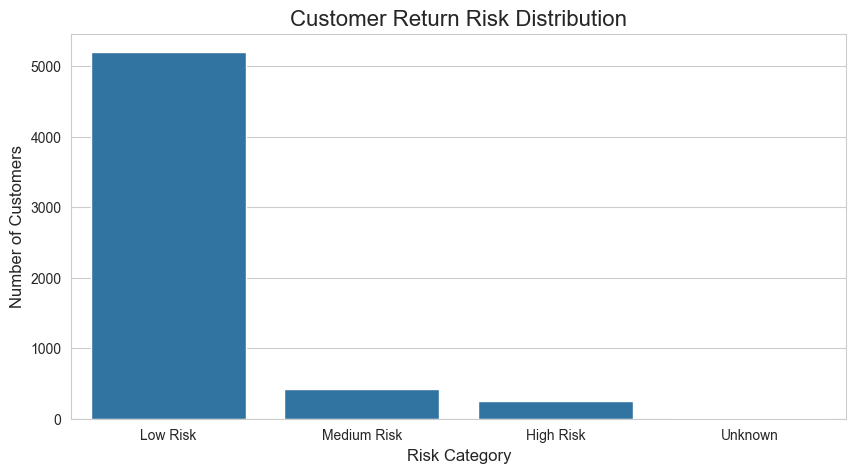

In [30]:
# ==============================
# RETURN RISK CATEGORY VISUALIZATION
# ==============================

risk_counts = (
    customer_analysis[
        "Return Risk Category"
    ]
    .value_counts()
    .reset_index()
)

risk_counts.columns = [
    "Risk Category",
    "Customer Count"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=risk_counts,
    x="Risk Category",
    y="Customer Count"
)

plt.title(
    "Customer Return Risk Distribution",
    fontsize=16
)

plt.xlabel(
    "Risk Category",
    fontsize=12
)

plt.ylabel(
    "Number of Customers",
    fontsize=12
)

plt.xticks(rotation=0)

plt.show()

In [31]:
# ==============================
# SQLITE CONNECTION
# ==============================

conn = sqlite3.connect(
    "../Database/revenue_leakage.db"
)

print("Connected to SQLite.")

Connected to SQLite.


In [32]:
# ==============================
# STORE CUSTOMER RETURN ANALYSIS
# ==============================

customer_analysis.to_sql(
    "uci_customer_return_analysis",
    conn,
    if_exists="replace",
    index=False
)

print("UCI analysis stored successfully.")

UCI analysis stored successfully.


In [33]:
# ==============================
# VERIFY SQLITE TABLE
# ==============================

query = """
SELECT *
FROM uci_customer_return_analysis
LIMIT 10
"""

pd.read_sql(query, conn)

,Customer ID,Sales Amount,Return Amount,Return Rate %,Suspicious Return Flag,Return Risk Category
0,12346.0,77556.46,77621.14,100.083397,1,High Risk
1,12347.0,5633.32,0.00,0.000000,0,Low Risk
2,12348.0,2019.40,0.00,0.000000,0,Low Risk
3,12349.0,4428.69,24.15,0.545308,0,Low Risk
4,12350.0,334.40,0.00,0.000000,0,Low Risk
5,12351.0,300.93,0.00,0.000000,0,Low Risk
6,12352.0,2849.84,960.63,33.708208,1,High Risk
7,12353.0,406.76,0.00,0.000000,0,Low Risk
8,12354.0,1079.40,0.00,0.000000,0,Low Risk
9,12355.0,947.61,0.00,0.000000,0,Low Risk


In [34]:
# ==============================
# UNKNOWN RISK CUSTOMERS
# ==============================

customer_analysis[
    customer_analysis["Return Risk Category"] == "Unknown"
]

,Customer ID,Sales Amount,Return Amount,Return Rate %,Suspicious Return Flag,Return Risk Category
904,13256.0,0.0,0.0,NaN,0,Unknown
1739,14103.0,0.0,0.0,NaN,0,Unknown
2458,14827.0,0.0,0.0,NaN,0,Unknown


In [35]:
# ==============================
# HANDLE NaN RETURN RATES
# ==============================

customer_analysis["Return Rate %"] = (
    customer_analysis["Return Rate %"]
    .fillna(0)
)

print("NaN return rates handled.")

NaN return rates handled.


In [36]:
# ==============================
# REBUILD RISK CATEGORY
# ==============================

conditions = [
    customer_analysis["Return Rate %"] <= 5,
    
    (customer_analysis["Return Rate %"] > 5)
    &
    (customer_analysis["Return Rate %"] <= 15),
    
    customer_analysis["Return Rate %"] > 15
]

categories = [
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

customer_analysis["Return Risk Category"] = np.select(
    conditions,
    categories,
    default="Low Risk"
)

customer_analysis[
    "Return Risk Category"
].value_counts()

Return Risk Category
Low Risk       5206
Medium Risk     424
High Risk       251
Name: count, dtype: int64